# Análisis explotario de datos y dashboard. Abandono de clientes en Telco

## Objetivo del proyecto
El objetivo es comprender el **por qué** los clientes abandonan la compañía telefónica Telco, y lograr predecir quiénes son los clientes que podrían irse. De esta manera, la compañía tendría la habilidad de actuar antes de perderlos. 

In [15]:
# Aquí están las librerías usadas en este notebook
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sea

### 1. Comprensión del dataset


In [16]:
df = pd.read_csv('../WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head(5)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**¿Qué es una fila?** 
Cada fila es un cliente único, distinguido por su customerID. Y en su correspondiente fila se expresa su comportamiento como Telco customer.

**¿Hay una columna Churn?** 
Así es. La última columna se llama **Churn** y tiene un valor de sí o no. Esto es importantísimo para el análisis porque entonces podemos comparar quiénes se fueron vs los que no se fueron. 

In [10]:
df.shape

(7043, 21)

In [11]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

El dataset está limpio. No cuenta con valores nulos por ningun sitio. De cualquier modo, esto será revisado más adelante con lujo de detalle.

In [12]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [13]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

El dataset muestra que 5174 de los customers (que representan un 73.4%) no se van de Telco, mientras que 1869 sí lo hacen (representando un 26.5%).

En total Telco cuenta entonces con 7043 clientes, cada fila con 21 columnas.
Hay un desbalance del 73% vs 27%. Aunque sí luce bastante manejable, no es extremo, podemos comprender el por qué sucede. 

### 2. Análisis por variable para inspección a detalle 

Analicemos con más detalle las variables *tenure*, *MonthlyCharges* y *Contract*, logrando comprender cómo se distribuyen los clientes.

#### Variable *tenure*

In [17]:
df['tenure'].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

Text(0.5, 1.0, 'Distribución de Tenure')

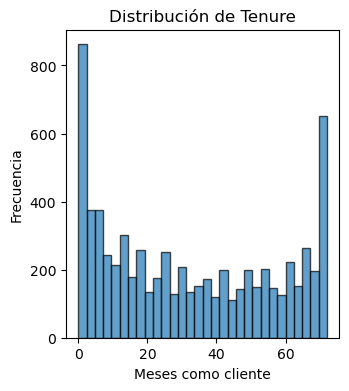

In [28]:
plt.subplot(1, 3, 1)
plt.hist(df['tenure'], bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Meses como cliente')
plt.ylabel('Frecuencia')
plt.title('Distribución de Tenure')

#### Variable *Monthly charges*

In [21]:
df['MonthlyCharges'].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

Text(0.5, 1.0, 'Distribución de cargos mensuales')

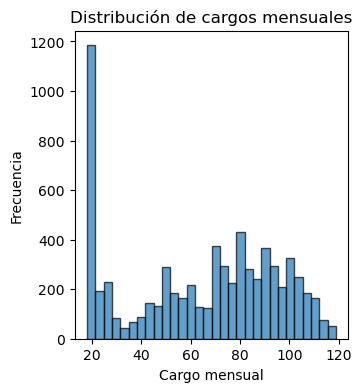

In [27]:
plt.subplot(1,3,2)
plt.hist(df['MonthlyCharges'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Cargo mensual')
plt.ylabel('Frecuencia')
plt.title('Distribución de cargos mensuales')

#### Variable Contract 

In [29]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

(array([0, 1, 2]),
 [Text(0, 0, 'Month-to-month'),
  Text(1, 0, 'Two year'),
  Text(2, 0, 'One year')])

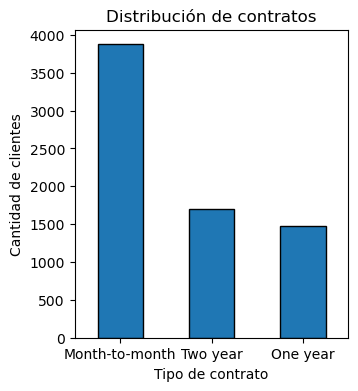

In [47]:
plt.subplot(1,3,3)
df['Contract'].value_counts().plot(kind='bar', edgecolor='black')
plt.xlabel('Tipo de contrato')
plt.ylabel('Cantidad de clientes')
plt.title('Distribución de contratos')
plt.xticks(rotation=0)
